## Day 4 — Compare False Positives vs False Negatives & Recommend Threshold

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

df_results = pd.read_csv("C:\\Users\\ABINAYA\\OneDrive\\Desktop\\predictive maintainence\\Week_4_Abinaya\\threshold_results.csv")

df_results.head()

,threshold,tp,fp,tn,fn,precision,recall,f1
0,0.10,67,474,1458,1,0.123845,0.985294,0.220033
1,0.15,67,343,1589,1,0.163415,0.985294,0.280335
2,0.20,67,264,1668,1,0.202417,0.985294,0.335840
3,0.25,67,195,1737,1,0.255725,0.985294,0.406061
4,0.30,67,159,1773,1,0.296460,0.985294,0.455782


In [6]:
thresholds_to_compare = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

fp_list = []
fn_list = []

for t in thresholds_to_compare:
    row = df_results[df_results["threshold"].round(2) == round(t, 2)]
    fp_list.append(int(row["fp"].values[0]))
    fn_list.append(int(row["fn"].values[0]))

print("Threshold | FP  | FN")
print("-" * 30)
for i, t in enumerate(thresholds_to_compare):
    print(f"{t:.2f}      | {fp_list[i]:3d} | {fn_list[i]:2d}")

Threshold | FP  | FN
------------------------------
0.30      | 159 |  1
0.40      |  99 |  1
0.50      |  67 |  2
0.60      |  38 |  2
0.70      |  23 |  3
0.80      |   6 |  3


In [7]:
comparison_df = pd.DataFrame({
    "Threshold": thresholds_to_compare,
    "False Positives (FP)": fp_list,
    "False Negatives (FN)": fn_list,
    "Total Errors (FP+FN)": [fp_list[i] + fn_list[i] for i in range(len(fp_list))]
})

comparison_df

,Threshold,False Positives (FP),False Negatives (FN),Total Errors (FP+FN)
0,0.3,159,1,160
1,0.4,99,1,100
2,0.5,67,2,69
3,0.6,38,2,40
4,0.7,23,3,26
5,0.8,6,3,9


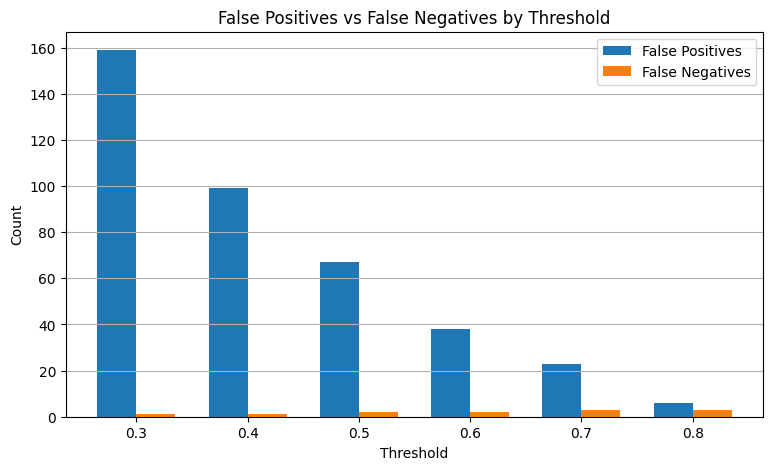

In [8]:
x = range(len(thresholds_to_compare))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar([i - width/2 for i in x], fp_list, width=width, label="False Positives")
plt.bar([i + width/2 for i in x], fn_list, width=width, label="False Negatives")

plt.title("False Positives vs False Negatives by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Count")
plt.xticks(list(x), [str(t) for t in thresholds_to_compare])
plt.legend()
plt.grid(axis="y")
plt.show()

In [9]:
recall_list = []
precision_list = []

for t in thresholds_to_compare:
    row = df_results[df_results["threshold"].round(2) == round(t, 2)]
    recall_list.append(float(row["recall"].values[0]))
    precision_list.append(float(row["precision"].values[0]))

trade_df = pd.DataFrame({
    "Threshold": thresholds_to_compare,
    "Recall": [round(r, 4) for r in recall_list],
    "Precision": [round(p, 4) for p in precision_list],
    "FP": fp_list,
    "FN": fn_list
})

trade_df

,Threshold,Recall,Precision,FP,FN
0,0.3,0.9853,0.2965,159,1
1,0.4,0.9853,0.4036,99,1
2,0.5,0.9706,0.4962,67,2
3,0.6,0.9706,0.6346,38,2
4,0.7,0.9559,0.7386,23,3
5,0.8,0.9559,0.9155,6,3


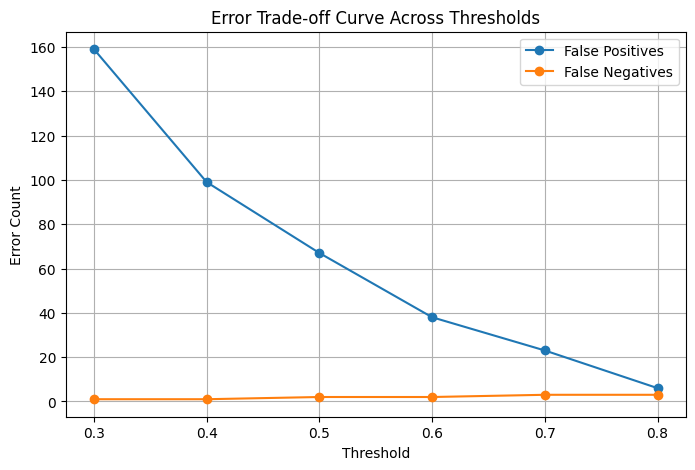

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(thresholds_to_compare, fp_list, marker='o', label="False Positives")
plt.plot(thresholds_to_compare, fn_list, marker='o', label="False Negatives")

plt.title("Error Trade-off Curve Across Thresholds")
plt.xlabel("Threshold")
plt.ylabel("Error Count")
plt.legend()
plt.grid(True)
plt.show()

### Final Decision Rule

We select threshold = 0.80 because:

- It minimizes total classification error (FP + FN = 9)
- It maintains high recall (>95%), ensuring most failures are detected
- It reduces operational overhead by eliminating excessive false alarms
- It provides the best F1-score among all tested thresholds

This threshold represents the optimal balance between predictive reliability and maintenance cost efficiency.